In [1]:
import os
import shutil
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, f1_score, roc_auc_score,roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectFromModel
import shap
import joblib

In [2]:
def split_boat_files(label_1_dir, keyword, boat_1_dir='boat_1', boat_0_dir='boat_0'):
    # Create output folders inside label_1_dir
    boat_1_path = os.path.join(label_1_dir, boat_1_dir)
    boat_0_path = os.path.join(label_1_dir, boat_0_dir)
    os.makedirs(boat_1_path, exist_ok=True)
    os.makedirs(boat_0_path, exist_ok=True)

    count_1, count_0 = 0, 0

    # Loop through files in label_1 directory
    for filename in os.listdir(label_1_dir):
        file_path = os.path.join(label_1_dir, filename)

        # Skip directories
        if os.path.isdir(file_path) or not filename.endswith(".wav"):
            continue

        # Check if keyword is in filename
        if keyword.lower() in filename.lower():
            dest_path = os.path.join(boat_1_path, filename)
            count_1 += 1
        else:
            dest_path = os.path.join(boat_0_path, filename)
            count_0 += 1

        shutil.move(file_path, dest_path)  # Use copy if needed

    print(f"Files containing '{keyword}' moved to '{boat_1_dir}': {count_1}")
    print(f"Remaining files moved to '{boat_0_dir}': {count_0}")


In [3]:
import os
import numpy as np
import librosa
from scipy.signal import butter, lfilter
import pandas as pd

# === Parameters ===
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 512
DURATION = 3  # in seconds
N_FRAMES = int((SAMPLE_RATE * DURATION) / HOP_LENGTH) + 1
N_BINS = N_FFT // 2 + 1

# === Bandpass Filter ===
def bandpass_filter(data, sr, lowcut, highcut):
    nyq = 0.5 * sr
    b, a = butter(4, [lowcut / nyq, highcut / nyq], btype='band')
    return lfilter(b, a, data)

# === Extract STFT Summary Features ===
def load_and_extract_stft_summary(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    y = bandpass_filter(y, sr, lowcut=100, highcut=4000)

    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    log_stft = librosa.amplitude_to_db(spectrogram, ref=np.max)

    # Pad or crop to fixed size
    if log_stft.shape[1] < N_FRAMES:
        pad_width = N_FRAMES - log_stft.shape[1]
        log_stft = np.pad(log_stft, ((0, 0), (0, pad_width)), mode='constant')
    elif log_stft.shape[1] > N_FRAMES:
        log_stft = log_stft[:, :N_FRAMES]

    # Compute summary stats over time axis (axis=1)
    mean = np.mean(log_stft, axis=1)
    std = np.std(log_stft, axis=1)
    min_ = np.min(log_stft, axis=1)
    max_ = np.max(log_stft, axis=1)

    feature_vector = np.hstack([mean, std, min_, max_])  # Shape: (4 × 513 = 2052)

    return feature_vector

# === Load Data for LightGBM ===
def load_data_for_lightgbm(folder_dict):
    X, y = [], []
    label_map = {name: i for i, name in enumerate(folder_dict)}
    for label, path in folder_dict.items():
        for file in os.listdir(path):
            if file.endswith(".wav"):
                try:
                    features = load_and_extract_stft_summary(os.path.join(path, file))
                    X.append(features)
                    y.append(label_map[label])
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    return np.array(X), np.array(y)


In [4]:
label_1_dir = "/Users/silent360/Meng_Study/GMU/DAEN690/Data/QiandaoEar22/label_1"
split_boat_files(label_1_dir, keyword="SpeedBoat")

Files containing 'SpeedBoat' moved to 'boat_1': 10639
Remaining files moved to 'boat_0': 6080


In [5]:
folder_paths = {
    "0": "/Users/silent360/Meng_Study/GMU/DAEN690/Data/QiandaoEar22/label_1/boat_0",
    "1": "/Users/silent360/Meng_Study/GMU/DAEN690/Data/QiandaoEar22/label_1/boat_1"
}

In [6]:
X, y = load_data_for_lightgbm(folder_paths)

PySoundFile failed. Trying audioread instead.
librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.


Error processing 20220628095213_M_TheEarl_N_M&TheKnight_N_M&QianDao_M_M&QianDao_M_M_2_label__1__27_1.wav: 
Error processing 20220628094211_M_Cargo_N_M&TheEarl_N_M&TheKnight_N_M&QianDao_N_M_2_label__1__25.wav: 
Error processing 20220628100715_M_QianDao_N_S&TheEarl_M_M&QianDao_M_M&QianDao_M_M_4_label__1__9.wav: 
Error processing 20220626170345_M_QianDao_F_W&SpeedBoat_M_M&SpeedBoat_F_W&SpeedBoat_F_W&SpeedBoat_F_W_0_label__1__8_1.wav: 
Error processing 20220628095713_M_TheEarl_N_M&TheKnight_N_M&SpeedBoat_F_W&SpeedBoat_F_W_1_label__1__8.wav: 
Error processing 20220626111239_M_SpeedBoat_F_W&SpeedBoat_F_W_2_label__1__22_1.wav: 
Error processing 20220626161837_M_SpeedBoat_M_M&SpeedBoat_M_M_2_label__1__3_1.wav: 
Error processing 20220626112743_M_GreenCity_M_M&SpeedBoat_M_M_0_label__1__23.wav: 
Error processing 20220628093209_M_GreenCity_N_S&SpeedBoat_N_S_1_label__1__10.wav: 
Error processing 20220628155321_M_QianDao_N_S&QianDao_N_S&SpeedBoat_M_M&SpeedBoat_M_M&SpeedBoat_F_W_3_label__1__15_1.wav:

In [7]:
X_df = pd.DataFrame(X)

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
baseline_model = LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 8503, number of negative: 4861
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 475888
[LightGBM] [Info] Number of data points in the train set: 13364, number of used features: 1891
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.636262 -> initscore=0.559175
[LightGBM] [Info] Start training from score 0.559175


LGBMClassifier(n_jobs=-1, objective='binary', random_state=42)

In [10]:
# Get feature importances
feature_importances = pd.Series(baseline_model.feature_importances_, index=np.arange(X.shape[1]))
feature_importances = feature_importances.sort_values(ascending=False)

# Keep top k features (e.g., 30%)
# top_k = int(len(feature_importances) * 0.3)
top_features = feature_importances.iloc[:50].index

# Filter X to only top features
X_train_reduced = X_train[:,top_features]
X_val_reduced = X_val[:,top_features]

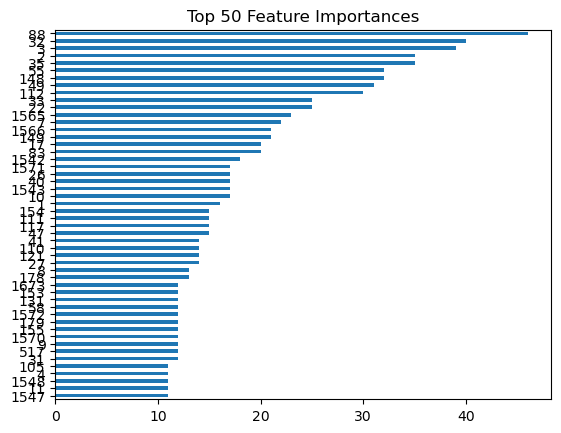

In [11]:
feature_importances.iloc[:50].plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 50 Feature Importances')
plt.show()

In [12]:
top_features_type = feature_importances[:50].index.tolist()

joblib.dump(top_features_type, 'features_type_50.joblib')

['features_type_50.joblib']

In [13]:
param_grid = {
    'num_leaves': [15, 31],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'min_child_samples': [20, 30],
    'lambda_l1': [0, 1.0],
    'lambda_l2': [0, 1.0],
}

grid_model = LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)
grid_search = GridSearchCV(grid_model, param_grid, scoring='roc_auc', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train_reduced, y_train)

best_model = grid_search.best_estimator_
print("Best Params:", grid_search.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Info] Number of positive: 6802, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 10691, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.636236 -> initscore=0.559065
[LightGBM] [Info] Start training from

In [14]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_model.predict(X_val_reduced)
y_prob = best_model.predict_proba(X_val_reduced)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))

[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1216
           1       0.99      0.97      0.98      2126

    accuracy                           0.97      3342
   macro avg       0.97      0.97      0.97      3342
weighted avg       0.97      0.97      0.97      3342

ROC AUC: 0.995233280313908


In [15]:
print("F1 Score:", f1_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_pred))
print("Accuracy:", accuracy_score(y_val, y_pred))

F1 Score: 0.9791765262659725
ROC-AUC: 0.9738478332178045
Accuracy: 0.9736684619988031


              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1216
           1       0.99      0.97      0.98      2126

    accuracy                           0.97      3342
   macro avg       0.97      0.97      0.97      3342
weighted avg       0.97      0.97      0.97      3342



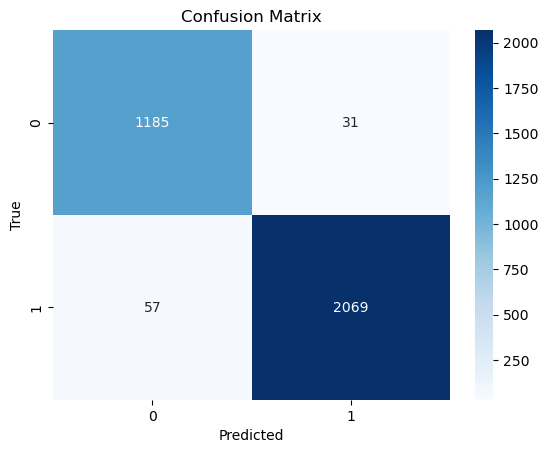

In [16]:
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0


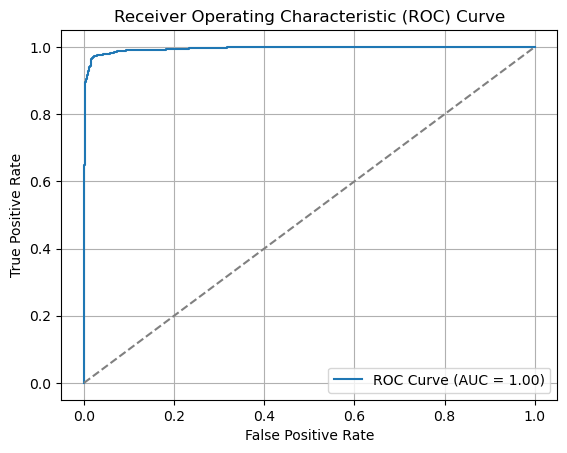

In [17]:

y_prob = best_model.predict_proba(X_val_reduced)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.show()

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


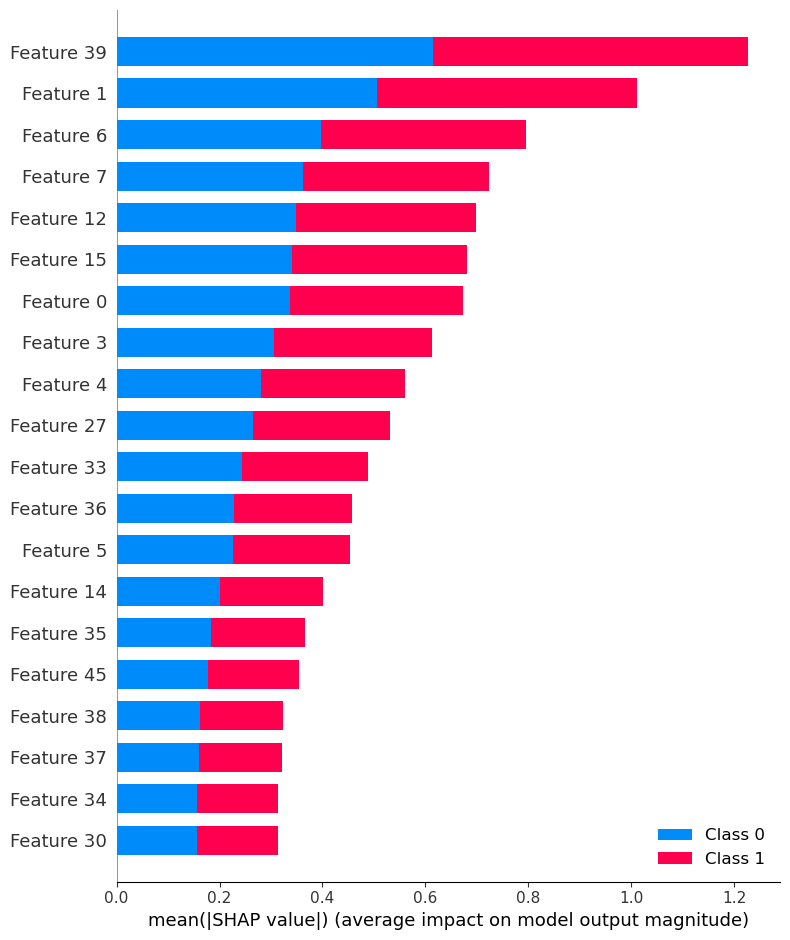

In [18]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_reduced)

shap.summary_plot(shap_values, X_val_reduced)

In [19]:
# Save model to file
joblib.dump(best_model, 'lightgbm_model_if_speedboat_50.joblib')

['lightgbm_model_if_speedboat_50.joblib']

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f